Title: RL_data_analysis_NM_KS_BC.ipynb

Purpose: Analyse the distributions from the output from the SEM with old bias corrected data

Author: Onno Nennecke on 17.04.2025 Modified: 09.04.2026

Input data: 

- Adjusted Model output: model_output_all.nc
    - This file lies here: '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc'

Output data:

- Plots: 2D_hist, Return_period_plot
    - These files lie here: /home/onennecke/Code/Figures/

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

In [2]:
# path = '/climca/people/onennecke/model_output/bias_corrected_masked/winter_data'

# files = sorted(glob.glob(os.path.join(path, '*.nc')))
# ds = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')

path = '/climca/people/onennecke/model_output/bias_corrected_masked_ibicus/final_model_output_with_SMARD_bc.nc'

ds = xr.open_dataset(path)
ds.load()

ts_datasets = ds.where((ds.ESM_run != 'ERA5_hist_wwd') & (ds.ESM_run != 'SMARD_hist'),drop=True)
ts_datasets.load()

ds_CMIP6 = ds.where((ds.ESM_run != 'ERA5_hist_week') & (ds.ESM_run != 'ERA5_hist_wwd') & (ds.ESM_run != 'SMARD_hist'),drop=True)
ds_CMIP6.load()

ds_ERA5 = ds.where(ds.ESM_run == 'ERA5_hist_week', drop=True)
ds_ERA5.load()

<xarray.Dataset> Size: 365kB
Dimensions:        (ESM_run: 1, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM            (ESM_run) <U10 40B 'ERA5_week'
    run            (ESM_run) <U8 32B 'hist'
  * ESM_run        (ESM_run) <U19 76B 'ERA5_hist_week'
    country        float64 8B 9.0
    period         <U4 16B 'week'
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    temp           (ESM_run, time) float64 29kB 1.323 3.335 ... 0.7396 0.4142
    demand         (ESM_run, time) float64 29kB 1.504e+03 ... 1.515e+03
    sfcWind        (ESM_run, time) float64 29kB 7.507 11.86 ... 8.049 8.775
    rsds           (ESM_run, time) float32 15kB 30.54 19.51 17.85 ... 26.3 31.92
    tas            (ESM_run, time) float32 15kB 1.771 3.587 ... 1.512 1.194
    tasmax         (ESM_run, time) float32 15kB 3.431 5.871 ... 2.709 3.361
    wind_off_prod  (ESM_run, time) float64 29kB 221.1 221.2 ... 221.1 221.1
    wind_on_prod   (ESM_run, time) float64 29kB 491.1 1.168e+03 ... 592.8 602.7
    solar_prod     (ESM_run, time) float64 29kB 90.32 45.84 ... 80.74 101.8
    total_prod     (ESM_run, time) float64 29kB 802.5 1.435e+03 ... 894.7 925.6
    Netto          (ESM_run, time) float64 29kB -701.0 -43.25 ... -616.1 -589.3
    Residual_load  (ESM_run, time) float64 29kB 701.0 43.25 ... 616.1 589.3

In [3]:
# Filter for winter months (October to March)
ts_winter = ts_datasets.where(ts_datasets['time.month'].isin([10, 11, 12, 1, 2, 3]), drop=True)

ts_high_RL = ts_datasets.where(ts_datasets['Residual_load'] >= 1319.138650687668, drop=True)

In [4]:
ts_high_RL

<xarray.Dataset> Size: 10MB
Dimensions:        (ESM_run: 100, time: 1184)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 9kB 2015-01-01 ... 2024-12-31
    ESM            (ESM_run) <U10 4kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-L'
    run            (ESM_run) <U8 3kB 'r1i1p1f1' 'r4i1p1f1' ... 'r9i1p1f2'
  * ESM_run        (ESM_run) <U19 8kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_...
    country        float64 8B 9.0
    period         <U4 16B 'week'
    doy            (time) int64 9kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    temp           (ESM_run, time) float64 947kB nan nan nan nan ... nan nan nan
    demand         (ESM_run, time) float64 947kB nan nan nan nan ... nan nan nan
    sfcWind        (ESM_run, time) float64 947kB nan nan nan nan ... nan nan nan
    rsds           (ESM_run, time) float32 474kB nan nan nan nan ... nan nan nan
    tas            (ESM_run, time) float32 474kB nan nan nan nan ... nan nan nan
    tasmax         (ESM_run, time) float32 474kB nan nan nan nan ... nan nan nan
    wind_off_prod  (ESM_run, time) float64 947kB nan nan nan nan ... nan nan nan
    wind_on_prod   (ESM_run, time) float64 947kB nan nan nan nan ... nan nan nan
    solar_prod     (ESM_run, time) float64 947kB nan nan nan nan ... nan nan nan
    total_prod     (ESM_run, time) float64 947kB nan nan nan nan ... nan nan nan
    Netto          (ESM_run, time) float64 947kB nan nan nan nan ... nan nan nan
    Residual_load  (ESM_run, time) float64 947kB nan nan nan nan ... nan nan nan

In [5]:
# Calculate a ESM mean 'ESM' (which is a secondary coordinate)
esm_mean = ts_datasets.groupby("ESM").mean(dim="ESM_run")
esm_mean

<xarray.Dataset> Size: 3MB
Dimensions:        (ESM: 11, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    country        float64 8B 9.0
    period         <U4 16B 'week'
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
  * ESM            (ESM) object 88B 'ACCESS-CM2' 'BCC-CSM2-M' ... 'UKESM1-0-L'
Data variables:
    temp           (ESM, time) float64 321kB 6.193 5.114 3.034 ... 4.945 4.683
    demand         (ESM, time) float64 321kB 1.443e+03 1.456e+03 ... 1.461e+03
    sfcWind        (ESM, time) float64 321kB 8.807 7.336 7.027 ... 6.708 7.208
    rsds           (ESM, time) float32 161kB 14.44 20.68 30.18 ... 23.25 24.78
    tas            (ESM, time) float32 161kB 5.55 4.635 2.698 ... 4.72 4.54
    tasmax         (ESM, time) float32 161kB 7.53 6.358 4.459 ... 6.412 6.053
    wind_off_prod  (ESM, time) float64 321kB 174.0 189.3 130.8 ... 126.0 136.7
    wind_on_prod   (ESM, time) float64 321kB 562.3 370.8 304.4 ... 308.9 387.2
    solar_prod     (ESM, time) float64 321kB 37.22 57.22 86.42 ... 66.68 70.81
    total_prod     (ESM, time) float64 321kB 773.5 617.3 521.6 ... 501.6 594.7
    Netto          (ESM, time) float64 321kB -669.1 -838.9 ... -956.4 -866.6
    Residual_load  (ESM, time) float64 321kB 669.1 838.9 960.7 ... 956.4 866.6

In [6]:
# ts_datasets['temp'].sel(ESM='ACCESS-CM2').values.flatten()
ts_datasets['temp'].where(ts_datasets['ESM'] == 'ACCESS-CM2', drop=True).values.flatten()

array([ 5.35256868,  2.44863356,  0.13012788, ..., -2.35757561,
       -3.76501324, -4.16902763])

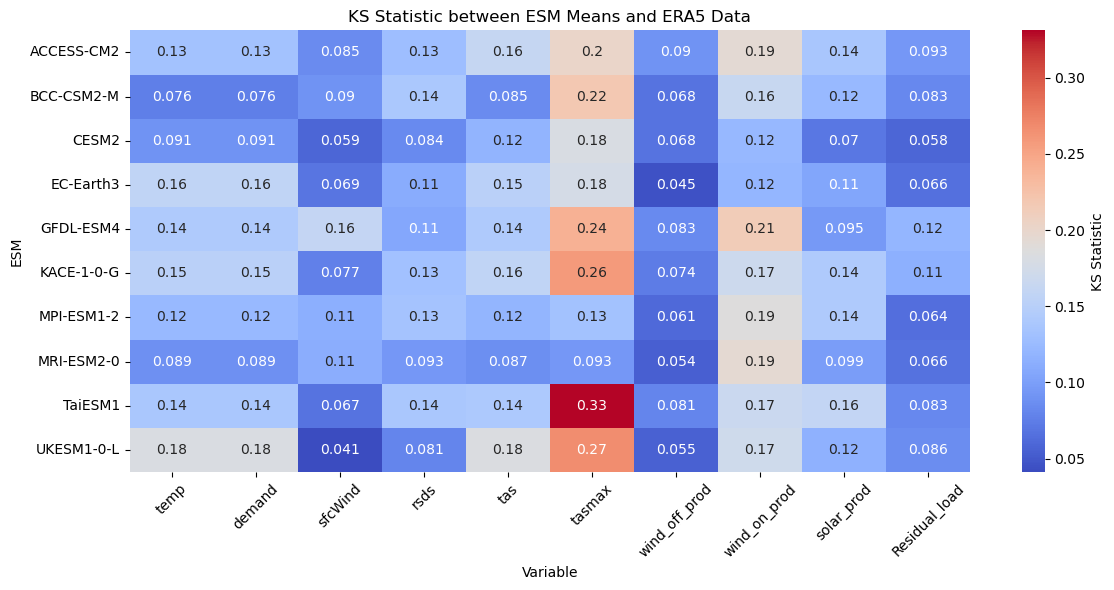

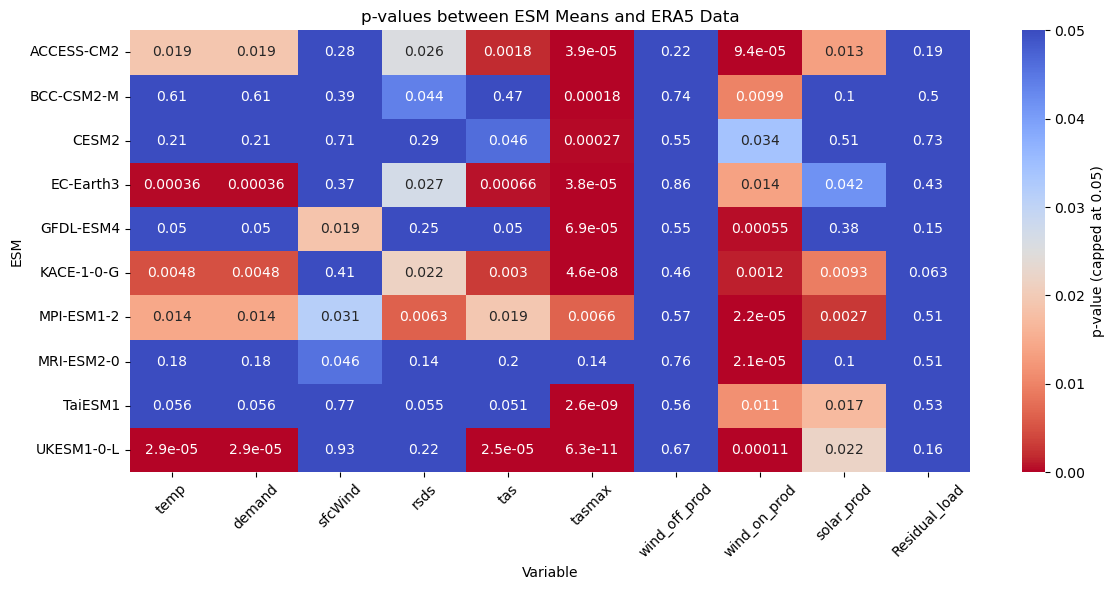

In [8]:
# Calculate the KS between the ESM means and the ERA5 data
ks_results = {}
esm_mean_vars = ['temp', 'demand', 'sfcWind', 'rsds', 'tas', 'tasmax', 'wind_off_prod', 'wind_on_prod', 'solar_prod', 'Residual_load']
for var in esm_mean_vars:
    for esm in esm_mean.ESM.values:
        if esm != 'ERA5_week':
            ks_stat, p_value = stats.ks_2samp(ts_high_RL[var].where(ts_high_RL['ESM'] == esm, drop=True).values.flatten()[~np.isnan(ts_high_RL[var].where(ts_high_RL['ESM'] == esm, drop=True).values.flatten())], ts_high_RL[var].where(ts_high_RL['ESM'] == 'ERA5_week', drop=True).values.flatten()[~np.isnan(ts_high_RL[var].where(ts_high_RL['ESM'] == 'ERA5_week', drop=True).values.flatten())])
            ks_results[(var, esm)] = (ks_stat, p_value)

# Convert the results to a DataFrame for better visualization
ks_df = pd.DataFrame.from_dict(ks_results, orient='index', columns=['KS_stat', 'p_value'])
ks_df.index = pd.MultiIndex.from_tuples(ks_df.index, names=['Variable', 'ESM'])
ks_df.reset_index(inplace=True)

# Plot a heatmap of the KS statistics with the ESMs on the y-axis and the variables on the x-axis
ks_pivot = ks_df.pivot(index='ESM', columns='Variable', values='KS_stat')

variable_order = [
    'temp', 'demand', 'sfcWind', 'rsds', 'tas', 'tasmax',
    'wind_off_prod', 'wind_on_prod', 'solar_prod', 'Residual_load'
]

# reorder columns safely (only keep those that exist)
ks_pivot = ks_pivot.reindex(columns=[v for v in variable_order if v in ks_pivot.columns])
plt.figure(figsize=(12, 6))
sns.heatmap(ks_pivot, annot=True, cmap='coolwarm', cbar_kws={'label': 'KS Statistic'})
plt.title('KS Statistic between ESM Means and ERA5 Data')
plt.ylabel('ESM')
plt.xlabel('Variable')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

ks_pivot_p = ks_df.pivot(index='ESM', columns='Variable', values='p_value')

# reorder columns safely (only keep those that exist)
ks_pivot_p = ks_pivot_p.reindex(columns=[v for v in variable_order if v in ks_pivot_p.columns])

p_thresh = 0.05

# Cap p-values at threshold
ks_pivot_p_plot = ks_pivot_p.clip(upper=p_thresh)

plt.figure(figsize=(12, 6))
sns.heatmap(
    ks_pivot_p_plot,
    annot=ks_pivot_p,
    # fmt=".2e",
    cmap='coolwarm_r',   # reversed
    vmin=0,
    vmax=p_thresh,
    cbar_kws={'label': f'p-value (capped at {p_thresh})'}
)

plt.title('p-values between ESM Means and ERA5 Data')
plt.ylabel('ESM')
plt.xlabel('Variable')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# plt.figure(figsize=(12, 6))
# sns.heatmap(ks_pivot_p, annot=True, cmap='coolwarm', cbar_kws={'label': 'p-value'})
# plt.title('p-values between ESM Means and ERA5 Data')
# plt.ylabel('ESM')
# plt.xlabel('Variable')
# plt.xticks(rotation=45)
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.show()

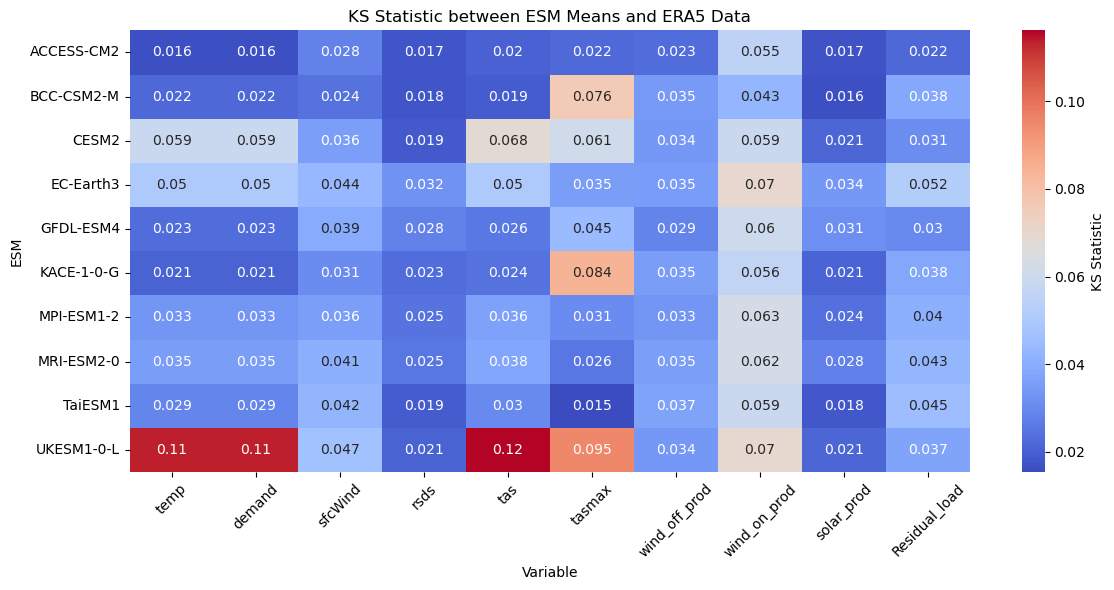

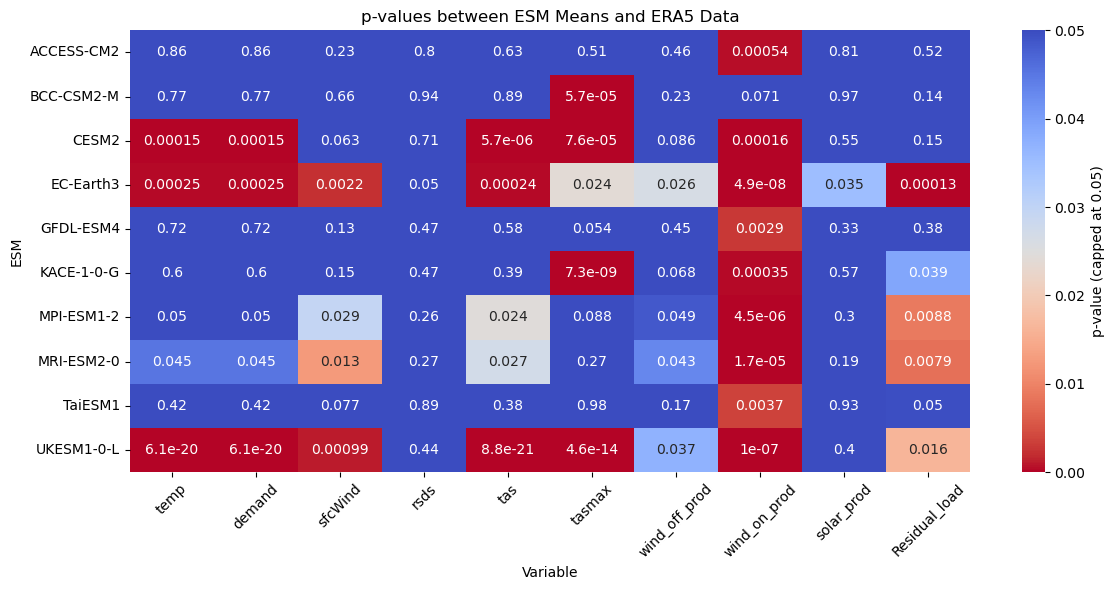

In [9]:
# Calculate the KS between the ESM means and the ERA5 data
ks_results = {}
esm_mean_vars = ['temp', 'demand', 'sfcWind', 'rsds', 'tas', 'tasmax', 'wind_off_prod', 'wind_on_prod', 'solar_prod', 'Residual_load']
for var in esm_mean_vars:
    for esm in esm_mean.ESM.values:
        if esm != 'ERA5_week':
            ks_stat, p_value = stats.ks_2samp(ts_winter[var].where(ts_winter['ESM'] == esm, drop=True).values.flatten(), ts_winter[var].where(ts_winter['ESM'] == 'ERA5_week', drop=True).values.flatten())
            ks_results[(var, esm)] = (ks_stat, p_value)

# Convert the results to a DataFrame for better visualization
ks_df = pd.DataFrame.from_dict(ks_results, orient='index', columns=['KS_stat', 'p_value'])
ks_df.index = pd.MultiIndex.from_tuples(ks_df.index, names=['Variable', 'ESM'])
ks_df.reset_index(inplace=True)

# Plot a heatmap of the KS statistics with the ESMs on the y-axis and the variables on the x-axis
ks_pivot = ks_df.pivot(index='ESM', columns='Variable', values='KS_stat')

variable_order = [
    'temp', 'demand', 'sfcWind', 'rsds', 'tas', 'tasmax',
    'wind_off_prod', 'wind_on_prod', 'solar_prod', 'Residual_load'
]

# reorder columns safely (only keep those that exist)
ks_pivot = ks_pivot.reindex(columns=[v for v in variable_order if v in ks_pivot.columns])
plt.figure(figsize=(12, 6))
sns.heatmap(ks_pivot, annot=True, cmap='coolwarm', cbar_kws={'label': 'KS Statistic'})
plt.title('KS Statistic between ESM Means and ERA5 Data')
plt.ylabel('ESM')
plt.xlabel('Variable')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

ks_pivot_p = ks_df.pivot(index='ESM', columns='Variable', values='p_value')

# reorder columns safely (only keep those that exist)
ks_pivot_p = ks_pivot_p.reindex(columns=[v for v in variable_order if v in ks_pivot_p.columns])

p_thresh = 0.05

# Cap p-values at threshold
ks_pivot_p_plot = ks_pivot_p.clip(upper=p_thresh)

plt.figure(figsize=(12, 6))
sns.heatmap(
    ks_pivot_p_plot,
    annot=ks_pivot_p,
    # fmt=".2e",
    cmap='coolwarm_r',   # reversed
    vmin=0,
    vmax=p_thresh,
    cbar_kws={'label': f'p-value (capped at {p_thresh})'}
)

plt.title('p-values between ESM Means and ERA5 Data')
plt.ylabel('ESM')
plt.xlabel('Variable')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# plt.figure(figsize=(12, 6))
# sns.heatmap(ks_pivot_p, annot=True, cmap='coolwarm', cbar_kws={'label': 'p-value'})
# plt.title('p-values between ESM Means and ERA5 Data')
# plt.ylabel('ESM')
# plt.xlabel('Variable')
# plt.xticks(rotation=45)
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.show()

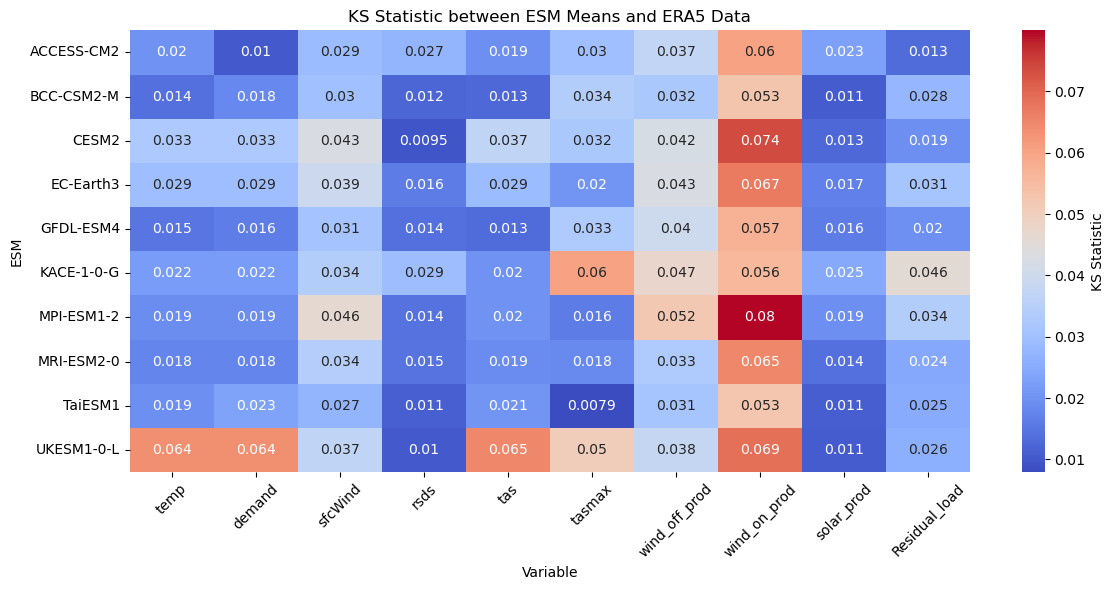

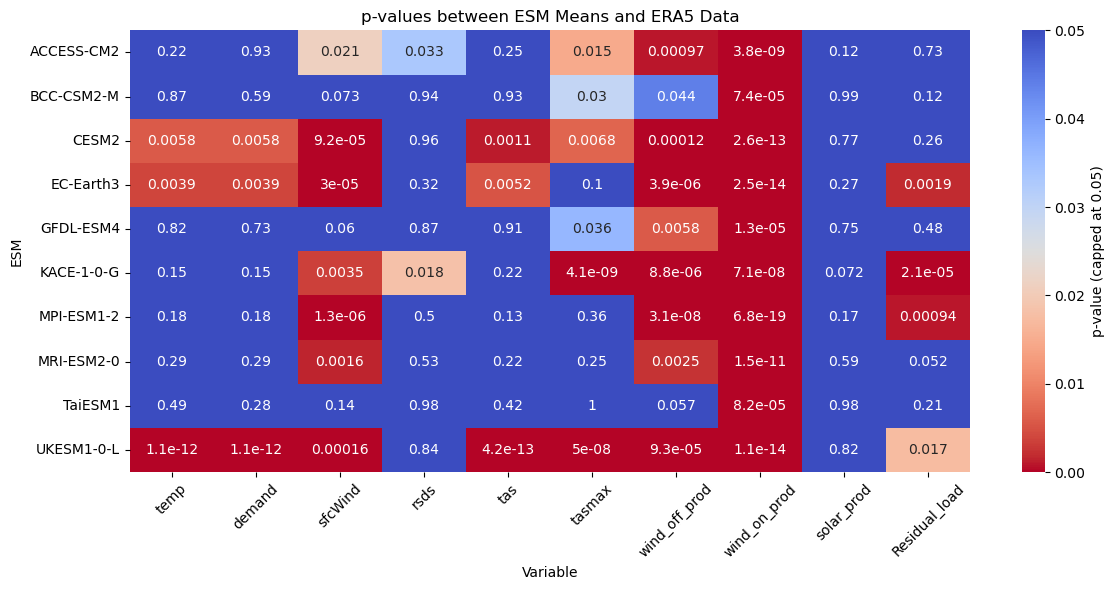

In [10]:
# Calculate the KS between the ESM means and the ERA5 data
ks_results = {}
esm_mean_vars = ['temp', 'demand', 'sfcWind', 'rsds', 'tas', 'tasmax', 'wind_off_prod', 'wind_on_prod', 'solar_prod', 'Residual_load']
for var in esm_mean_vars:
    for esm in esm_mean.ESM.values:
        if esm != 'ERA5_week':
            ks_stat, p_value = stats.ks_2samp(ts_datasets[var].where(ts_datasets['ESM'] == esm, drop=True).values.flatten(), ts_datasets[var].where(ts_datasets['ESM'] == 'ERA5_week', drop=True).values.flatten())
            ks_results[(var, esm)] = (ks_stat, p_value)

# Convert the results to a DataFrame for better visualization
ks_df = pd.DataFrame.from_dict(ks_results, orient='index', columns=['KS_stat', 'p_value'])
ks_df.index = pd.MultiIndex.from_tuples(ks_df.index, names=['Variable', 'ESM'])
ks_df.reset_index(inplace=True)

# Plot a heatmap of the KS statistics with the ESMs on the y-axis and the variables on the x-axis
ks_pivot = ks_df.pivot(index='ESM', columns='Variable', values='KS_stat')

variable_order = [
    'temp', 'demand', 'sfcWind', 'rsds', 'tas', 'tasmax',
    'wind_off_prod', 'wind_on_prod', 'solar_prod', 'Residual_load'
]

# reorder columns safely (only keep those that exist)
ks_pivot = ks_pivot.reindex(columns=[v for v in variable_order if v in ks_pivot.columns])
plt.figure(figsize=(12, 6))
sns.heatmap(ks_pivot, annot=True, cmap='coolwarm', cbar_kws={'label': 'KS Statistic'})
plt.title('KS Statistic between ESM Means and ERA5 Data')
plt.ylabel('ESM')
plt.xlabel('Variable')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

ks_pivot_p = ks_df.pivot(index='ESM', columns='Variable', values='p_value')

# reorder columns safely (only keep those that exist)
ks_pivot_p = ks_pivot_p.reindex(columns=[v for v in variable_order if v in ks_pivot_p.columns])

p_thresh = 0.05

# Cap p-values at threshold
ks_pivot_p_plot = ks_pivot_p.clip(upper=p_thresh)

plt.figure(figsize=(12, 6))
sns.heatmap(
    ks_pivot_p_plot,
    annot=ks_pivot_p,
    # fmt=".2e",
    cmap='coolwarm_r',   # reversed
    vmin=0,
    vmax=p_thresh,
    cbar_kws={'label': f'p-value (capped at {p_thresh})'}
)

plt.title('p-values between ESM Means and ERA5 Data')
plt.ylabel('ESM')
plt.xlabel('Variable')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# plt.figure(figsize=(12, 6))
# sns.heatmap(ks_pivot_p, annot=True, cmap='coolwarm', cbar_kws={'label': 'p-value'})
# plt.title('p-values between ESM Means and ERA5 Data')
# plt.ylabel('ESM')
# plt.xlabel('Variable')
# plt.xticks(rotation=45)
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.show()

In [18]:
esm_mean.ESM.values

array(['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'ERA5_week',
       'GFDL-ESM4', 'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0',
       'TaiESM1', 'UKESM1-0-LL'], dtype=object)

In [27]:
# Calculate the KS between the ESM means and the ERA5 data
ks_results = {}
esm_mean_vars = ['temp', 'demand', 'sfcWind', 'rsds', 'tas', 'tasmax', 'wind_off_prod', 'wind_on_prod', 'solar_prod', 'Residual_load']
for var in esm_mean_vars:
    for esm in esm_mean.ESM.values:
        if esm != 'ERA5_week':
            ks_stat, p_value = stats.ks_2samp(esm_mean[var].sel(ESM=esm).values.flatten(), esm_mean[var].sel(ESM='ERA5_week').values.flatten())
            ks_results[(var, esm)] = (ks_stat, p_value)

# Convert the results to a DataFrame for better visualization
ks_df = pd.DataFrame.from_dict(ks_results, orient='index', columns=['KS_stat', 'p_value'])
ks_df.index = pd.MultiIndex.from_tuples(ks_df.index, names=['Variable', 'ESM'])
ks_df.reset_index(inplace=True)
ks_df


,Variable,ESM,KS_stat,p_value
0,temp,ACCESS-CM2,0.134795,2.601461e-29
1,temp,BCC-CSM2-MR,0.097260,1.924441e-15
2,temp,CESM2,0.158082,3.360286e-40
3,temp,EC-Earth3,0.143014,5.924237e-33
4,temp,GFDL-ESM4,0.101096,1.187032e-16
...,...,...,...,...
95,Residual_load,KACE-1-0-G,0.372603,7.263274e-226
96,Residual_load,MPI-ESM1-2-HR,0.207397,4.256421e-69
97,Residual_load,MRI-ESM2-0,0.193425,4.241832e-60
98,Residual_load,TaiESM1,0.108493,4.056058e-19


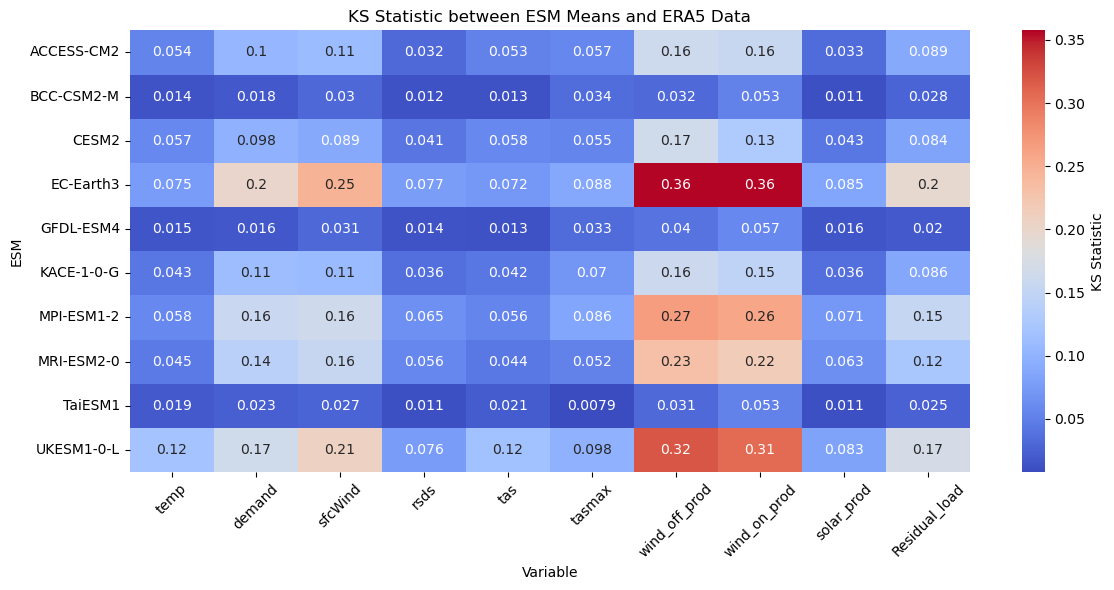

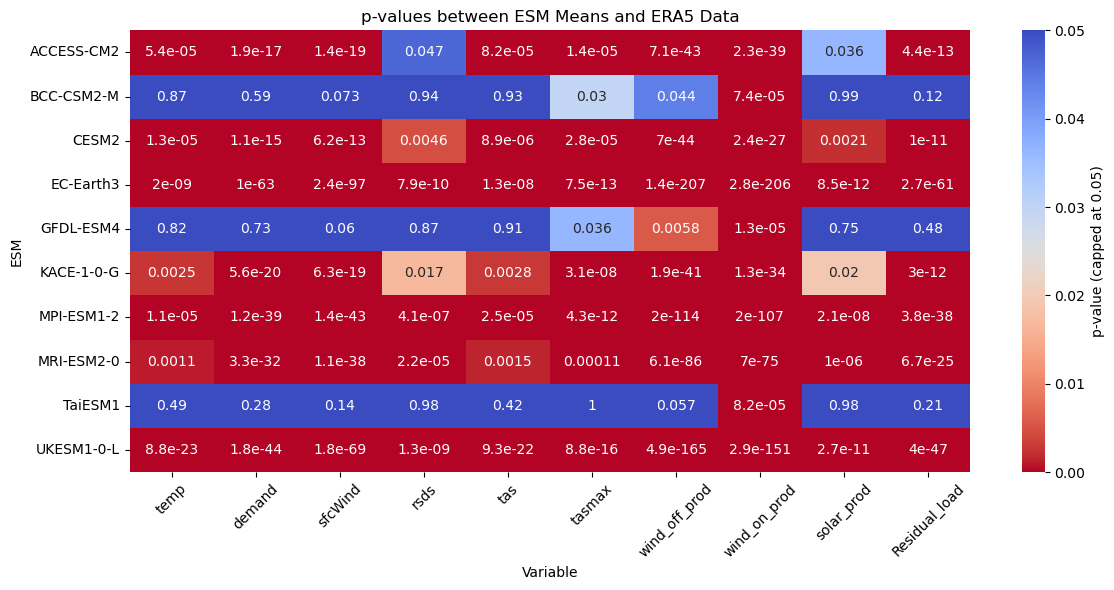

In [11]:
# Calculate the KS between the ESM means and the ERA5 data
ks_results = {}
esm_mean_vars = ['temp', 'demand', 'sfcWind', 'rsds', 'tas', 'tasmax', 'wind_off_prod', 'wind_on_prod', 'solar_prod', 'Residual_load']
for var in esm_mean_vars:
    for esm in esm_mean.ESM.values:
        if esm != 'ERA5_week':
            ks_stat, p_value = stats.ks_2samp(esm_mean[var].sel(ESM=esm).values.flatten(), esm_mean[var].sel(ESM='ERA5_week').values.flatten())
            ks_results[(var, esm)] = (ks_stat, p_value)

# Convert the results to a DataFrame for better visualization
ks_df = pd.DataFrame.from_dict(ks_results, orient='index', columns=['KS_stat', 'p_value'])
ks_df.index = pd.MultiIndex.from_tuples(ks_df.index, names=['Variable', 'ESM'])
ks_df.reset_index(inplace=True)

# Plot a heatmap of the KS statistics with the ESMs on the y-axis and the variables on the x-axis
ks_pivot = ks_df.pivot(index='ESM', columns='Variable', values='KS_stat')

variable_order = [
    'temp', 'demand', 'sfcWind', 'rsds', 'tas', 'tasmax',
    'wind_off_prod', 'wind_on_prod', 'solar_prod', 'Residual_load'
]

# reorder columns safely (only keep those that exist)
ks_pivot = ks_pivot.reindex(columns=[v for v in variable_order if v in ks_pivot.columns])
plt.figure(figsize=(12, 6))
sns.heatmap(ks_pivot, annot=True, cmap='coolwarm', cbar_kws={'label': 'KS Statistic'})
plt.title('KS Statistic between ESM Means and ERA5 Data')
plt.ylabel('ESM')
plt.xlabel('Variable')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

ks_pivot_p = ks_df.pivot(index='ESM', columns='Variable', values='p_value')

# reorder columns safely (only keep those that exist)
ks_pivot_p = ks_pivot_p.reindex(columns=[v for v in variable_order if v in ks_pivot_p.columns])

p_thresh = 0.05

# Cap p-values at threshold
ks_pivot_p_plot = ks_pivot_p.clip(upper=p_thresh)

plt.figure(figsize=(12, 6))
sns.heatmap(
    ks_pivot_p_plot,
    annot=ks_pivot_p,
    # fmt=".2e",
    cmap='coolwarm_r',   # reversed
    vmin=0,
    vmax=p_thresh,
    cbar_kws={'label': f'p-value (capped at {p_thresh})'}
)

plt.title('p-values between ESM Means and ERA5 Data')
plt.ylabel('ESM')
plt.xlabel('Variable')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# plt.figure(figsize=(12, 6))
# sns.heatmap(ks_pivot_p, annot=True, cmap='coolwarm', cbar_kws={'label': 'p-value'})
# plt.title('p-values between ESM Means and ERA5 Data')
# plt.ylabel('ESM')
# plt.xlabel('Variable')
# plt.xticks(rotation=45)
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.show()